In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as snippets

In [18]:
df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv")


In [20]:
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [21]:
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [22]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("%", "")
)
df.head()

,school_dbn,school_name,school_level,regents_exam,year,total_tested,mean_score,number_scoring_below_65,percent_scoring_below_65,number_scoring_65_or_above,percent_scoring_65_or_above,number_scoring_80_or_above,percent_scoring_80_or_above,number_scoring_cr,percent_scoring_cr
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [64]:
df['percent_scoring_80_or_above'] = (
    df['percent_scoring_80_or_above']
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("s", "nan", regex=False)
    .astype(float)
)

In [63]:
df[df['school_name'].str.contains("Franklin D. Roosevelt", case=False)]

,school_dbn,school_name,school_level,regents_exam,year,total_tested,mean_score,number_scoring_below_65,percent_scoring_below_65,number_scoring_65_or_above,percent_scoring_65_or_above,number_scoring_80_or_above,percent_scoring_80_or_above,number_scoring_cr,percent_scoring_cr,borough
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,NaN,s,NaN,na,na,Manhattan
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
19478,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,3,s,s,s,s,NaN,s,NaN,na,na,Manhattan
19479,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,1,s,s,s,s,NaN,s,NaN,na,na,Manhattan
19480,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
19481,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
54234,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,3,s,s,s,s,NaN,s,NaN,na,na,Manhattan
54235,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,1,s,s,s,s,NaN,s,NaN,na,na,Manhattan
54236,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,1,s,s,s,s,NaN,s,NaN,na,na,Manhattan


In [26]:
df['borough'] = df['school_dbn'].str[2]

borough_map = {
    'M': 'Manhattan',
    'X': 'Bronx',
    'K': 'Brooklyn',
    'Q': 'Queens',
    'R': 'Staten Island'
}
df['borough'] = df['borough'].map(borough_map)

manhattan = df[df['borough'] == "Manhattan"]

In [57]:
stuy = df[df['school_name'].str.contains("", case=False)]

In [ ]:
df[df['school_name'].str.contains("Franklin D. Roosevelt", case=False)]

,school_dbn,school_name,school_level,regents_exam,year,total_tested,mean_score,number_scoring_below_65,percent_scoring_below_65,number_scoring_65_or_above,percent_scoring_65_or_above,number_scoring_80_or_above,percent_scoring_80_or_above,number_scoring_cr,percent_scoring_cr,borough
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,NaN,s,s,na,na,Manhattan
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
19478,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,3,s,s,s,s,NaN,s,s,na,na,Manhattan
19479,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,1,s,s,s,s,NaN,s,s,na,na,Manhattan
19480,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
19481,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
54234,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,3,s,s,s,s,NaN,s,s,na,na,Manhattan
54235,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,1,s,s,s,s,NaN,s,s,na,na,Manhattan
54236,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,1,s,s,s,s,NaN,s,s,na,na,Manhattan


In [ ]:
df[df['school_name'].str.contains("Franklin D. Roosevelt", case=False)]

,school_dbn,school_name,school_level,regents_exam,year,total_tested,mean_score,number_scoring_below_65,percent_scoring_below_65,number_scoring_65_or_above,percent_scoring_65_or_above,number_scoring_80_or_above,percent_scoring_80_or_above,number_scoring_cr,percent_scoring_cr,borough
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,NaN,s,s,na,na,Manhattan
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
19478,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,3,s,s,s,s,NaN,s,s,na,na,Manhattan
19479,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,1,s,s,s,s,NaN,s,s,na,na,Manhattan
19480,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
19481,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
54234,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,3,s,s,s,s,NaN,s,s,na,na,Manhattan
54235,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,1,s,s,s,s,NaN,s,s,na,na,Manhattan
54236,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,1,s,s,s,s,NaN,s,s,na,na,Manhattan


In [62]:
df[df['school_name'].str.contains("Franklin D. Roosevelt", case=False)]

,school_dbn,school_name,school_level,regents_exam,year,total_tested,mean_score,number_scoring_below_65,percent_scoring_below_65,number_scoring_65_or_above,percent_scoring_65_or_above,number_scoring_80_or_above,percent_scoring_80_or_above,number_scoring_cr,percent_scoring_cr,borough
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,NaN,s,NaN,na,na,Manhattan
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
19478,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,3,s,s,s,s,NaN,s,NaN,na,na,Manhattan
19479,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,1,s,s,s,s,NaN,s,NaN,na,na,Manhattan
19480,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
19481,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
54234,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,3,s,s,s,s,NaN,s,NaN,na,na,Manhattan
54235,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,1,s,s,s,s,NaN,s,NaN,na,na,Manhattan
54236,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,1,s,s,s,s,NaN,s,NaN,na,na,Manhattan


In [54]:
NYC = df

In [83]:
frank = df[df['school_name'].str.contains("Franklin D. Roosevelt", case=False)]
frank_stats = frank['percent_scoring_80_or_above'].describe()
nyc_stats = nyc ['percent_scoring_80_or_above'].describe()

frank_stats, nyc_stats

(count    10.000000
 mean     38.600000
 std      12.968423
 min      16.700000
 25%      27.375000
 50%      43.800000
 75%      48.600000
 max      50.000000
 Name: percent_scoring_80_or_above, dtype: float64,
 count    137109.000000
 mean         22.692027
 std          26.160987
 min           0.000000
 25%           2.200000
 50%          12.500000
 75%          34.500000
 max         100.000000
 Name: percent_scoring_80_or_above, dtype: float64)

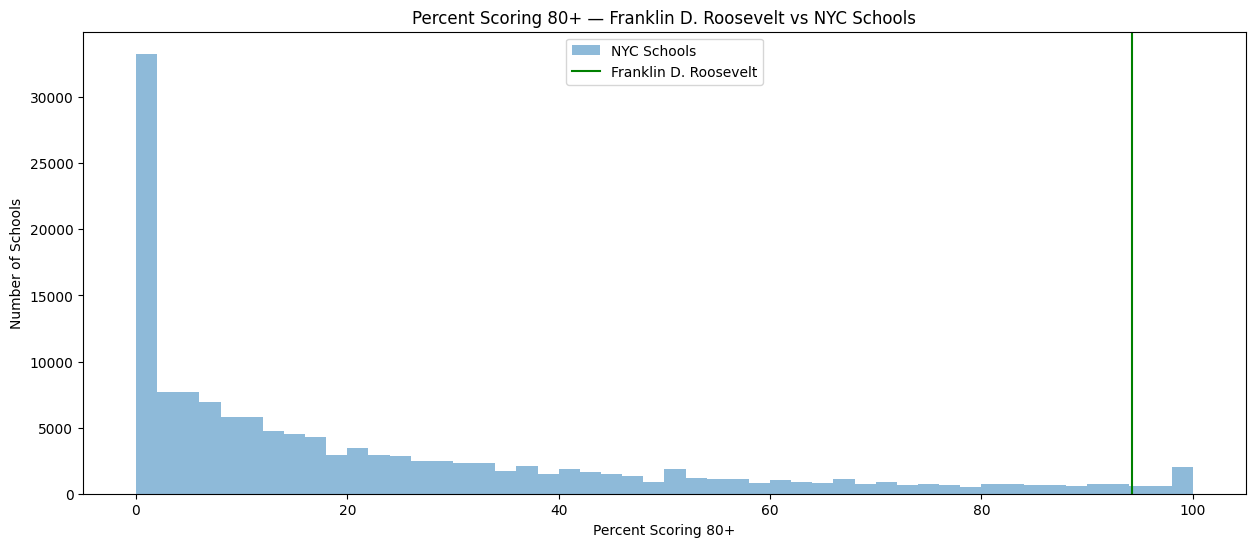

In [88]:
plt.figure(figsize=(15,6))
plt.hist(nyc['percent_scoring_80_or_above'], bins=50, alpha=0.5, label='NYC Schools')
plt.axvline(Frank_stats['mean'], color='green', label='Franklin D. Roosevelt')
plt.title("Percent Scoring 80+ — Franklin D. Roosevelt vs NYC Schools")
plt.xlabel("Percent Scoring 80+")
plt.ylabel("Number of Schools")
plt.legend()
plt.show()
